In [3]:
# using this paper as inspo - try and use a load as a proxy for the FMU https://docs.nrel.gov/docs/fy25osti/91114.pdf



In [4]:
import sqlite3
import pandas as pd
import numpy as np

# Correct path to the database (fixed typo: "exanples" -> "examples")
database_path = "../examples/WECGrid.db"

# Connect to database and pull WEC simulation data
conn = sqlite3.connect(database_path)

# First, let's see what WEC simulations are available
wec_sims_df = pd.read_sql_query("SELECT * FROM wec_simulations", conn)
print("Available WEC Simulations:")
print(wec_sims_df.to_string())
print(f"\nTotal simulations: {len(wec_sims_df)}")

Available WEC Simulations:
   wec_sim_id model_type  sim_duration_sec  delta_time  wave_height_m  wave_period_sec wave_spectrum wave_class  wave_seed   simulation_hash           created_at
0           1        RM3           86400.0         0.1            2.5              8.0            PM  irregular         94  RM3_2.5m_8.0s_94  2025-08-19 19:45:01
1           2       LUPA           86400.0         0.1            2.5              8.0            PM  irregular          8  LUPA_2.5m_8.0s_8  2025-08-19 19:59:49

Total simulations: 2


In [5]:
# Pull power results for wec_sim_id = 1 (RM3 model)
wec_sim_id = 1

wec_power_df = pd.read_sql_query(f"""
    SELECT 
        time_sec,
        device_index,
        p_w,
        q_var,
        wave_elevation_m
    FROM wec_power_results 
    WHERE wec_sim_id = {wec_sim_id}
    ORDER BY time_sec, device_index
""", conn)

print(f"WEC Power Results for sim_id={wec_sim_id}:")
print(f"Shape: {wec_power_df.shape}")
print(f"Time range: {wec_power_df['time_sec'].min():.2f}s to {wec_power_df['time_sec'].max():.2f}s")
print(f"Unique devices: {wec_power_df['device_index'].unique()}")
print(f"\nFirst few rows:")
print(wec_power_df.head(10))
print(f"\nPower statistics (Watts):")
print(wec_power_df['p_w'].describe())

WEC Power Results for sim_id=1:
Shape: (864001, 5)
Time range: 0.00s to 86400.00s
Unique devices: [1]

First few rows:
   time_sec  device_index        p_w  q_var  wave_elevation_m
0       0.0             1   0.000000    0.0         -0.694602
1       0.1             1   0.077340    0.0         -0.701553
2       0.2             1   0.457800    0.0         -0.709366
3       0.3             1   1.506465    0.0         -0.719254
4       0.4             1   3.687610    0.0         -0.731727
5       0.5             1   7.378399    0.0         -0.746488
6       0.6             1  12.743097    0.0         -0.762442
7       0.7             1  19.703850    0.0         -0.777779
8       0.8             1  27.998020    0.0         -0.790154
9       0.9             1  37.250772    0.0         -0.796923

Power statistics (Watts):
count    864001.000000
mean      17162.439831
std        3590.010938
min           0.000000
25%       14705.373012
50%       17002.183985
75%       19393.279737
max       3

In [7]:
# Prepare P and Q data for injection into OpenDSS load
# Aggregate power across all devices (sum for a WEC farm)
wec_farm_power = wec_power_df.groupby('time_sec').agg({
    'p_w': 'sum',      # Total active power (Watts)
    'q_var': 'sum',    # Total reactive power (VAR)
    'wave_elevation_m': 'first'  # Wave elevation (same for all devices)
}).reset_index()

# Convert to kW and kVAR for OpenDSS (typical distribution system units)
wec_farm_power['p_kw'] = wec_farm_power['p_w'] / 1000
wec_farm_power['q_kvar'] = wec_farm_power['q_var'] / 1000

print("WEC Farm Aggregated Power (ready for OpenDSS injection):")
print(f"Shape: {wec_farm_power.shape}")
print(f"\nFirst 10 timesteps:")
print(wec_farm_power.head(10))
print(f"\nPower Statistics:")
print(f"  P range: {wec_farm_power['p_kw'].min():.2f} to {wec_farm_power['p_kw'].max():.2f} kW")
print(f"  Q range: {wec_farm_power['q_kvar'].min():.2f} to {wec_farm_power['q_kvar'].max():.2f} kVAR")
print(f"  Mean P: {wec_farm_power['p_kw'].mean():.2f} kW")

# Close database connection
conn.close()

WEC Farm Aggregated Power (ready for OpenDSS injection):
Shape: (864001, 6)

First 10 timesteps:
   time_sec        p_w  q_var  wave_elevation_m      p_kw  q_kvar
0       0.0   0.000000    0.0         -0.694602  0.000000     0.0
1       0.1   0.077340    0.0         -0.701553  0.000077     0.0
2       0.2   0.457800    0.0         -0.709366  0.000458     0.0
3       0.3   1.506465    0.0         -0.719254  0.001506     0.0
4       0.4   3.687610    0.0         -0.731727  0.003688     0.0
5       0.5   7.378399    0.0         -0.746488  0.007378     0.0
6       0.6  12.743097    0.0         -0.762442  0.012743     0.0
7       0.7  19.703850    0.0         -0.777779  0.019704     0.0
8       0.8  27.998020    0.0         -0.790154  0.027998     0.0
9       0.9  37.250772    0.0         -0.796923  0.037251     0.0

Power Statistics:
  P range: 0.00 to 30.91 kW
  Q range: 0.00 to 0.00 kVAR
  Mean P: 17.16 kW


In [ ]:
# psse set-up 

In [11]:
import pssepath

pssepath.add_pssepath()
import psspy
import psse35

psse35.set_minor(3)
psspy.psseinit(50)  # need to update based on grid size

0

In [12]:
# Load IEEE 14-bus case
import os

# Path to the IEEE 14-bus case file
case_path = r"../cpds_cosim/machine_1/Transmission/ieee_14/ieee14.cnv"

# Read the saved case
ierr = psspy.case(case_path)
if ierr == 0:
    print(f"Successfully loaded case: {case_path}")
else:
    print(f"Error loading case. Error code: {ierr}")

# Run power flow to establish base conditions
ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])  # Full Newton-Raphson power flow
if ierr == 0:
    print("Power flow solved successfully!")
else:
    print(f"Power flow error code: {ierr}")



  IEEE 14 BUS TEST CASE
  03/06/14 CONTO           100.0  1962 W

 The Saved Case in file c:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.cnv was saved on FRI, APR 05 2024  10:46
Successfully loaded case: ../cpds_cosim/machine_1/Transmission/ieee_14/ieee14.cnv

 Messages for api FNSL
 Generators are "converted"   (001755)
Power flow error code: 2


In [13]:
# Get system information - buses, loads, generators
print("=== IEEE 14-Bus System Summary ===\n")

# Get bus data
ierr, bus_numbers = psspy.abusint(-1, 2, 'NUMBER')
ierr, bus_names = psspy.abuschar(-1, 2, 'NAME')
ierr, bus_voltages = psspy.abusreal(-1, 2, 'PU')

print("Buses:")
for i, (num, name, volt) in enumerate(zip(bus_numbers[0], bus_names[0], bus_voltages[0])):
    print(f"  Bus {num}: {name.strip()} - V = {volt:.4f} pu")

# Get load data
ierr, load_buses = psspy.aloadint(-1, 4, 'NUMBER')
ierr, load_ids = psspy.aloadchar(-1, 4, 'ID')
ierr, load_pq = psspy.aloadcplx(-1, 4, 'MVAACT')

print("\nLoads:")
if load_buses[0]:
    for bus, lid, pq in zip(load_buses[0], load_ids[0], load_pq[0]):
        print(f"  Bus {bus} (ID={lid.strip()}): P = {pq.real:.2f} MW, Q = {pq.imag:.2f} MVAr")
else:
    print("  No loads found")

# Get generator data
ierr, gen_buses = psspy.amachint(-1, 4, 'NUMBER')
ierr, gen_ids = psspy.amachchar(-1, 4, 'ID')
ierr, gen_pq = psspy.amachcplx(-1, 4, 'PQGEN')

print("\nGenerators:")
if gen_buses[0]:
    for bus, gid, pq in zip(gen_buses[0], gen_ids[0], gen_pq[0]):
        print(f"  Bus {bus} (ID={gid.strip()}): P = {pq.real:.2f} MW, Q = {pq.imag:.2f} MVAr")

=== IEEE 14-Bus System Summary ===

Buses:
  Bus 1: BUS1 - V = 1.0300 pu
  Bus 2: BUS2 - V = 1.0197 pu
  Bus 3: BUS3 - V = 1.0004 pu
  Bus 4: BUS4 - V = 0.9986 pu
  Bus 5: BUS5 - V = 1.0044 pu
  Bus 6: BUS6 - V = 0.9987 pu
  Bus 7: BUS7 - V = 1.0068 pu
  Bus 8: BUS8 - V = 1.0189 pu
  Bus 9: BUS9 - V = 1.0019 pu
  Bus 10: BUS10 - V = 0.9935 pu
  Bus 11: BUS11 - V = 0.9924 pu
  Bus 12: BUS12 - V = 0.9864 pu
  Bus 13: BUS13 - V = 0.9840 pu
  Bus 14: BUS14 - V = 0.9906 pu

Loads:
  Bus 2 (ID=1): P = 21.70 MW, Q = 12.70 MVAr
  Bus 3 (ID=1): P = 50.00 MW, Q = 25.00 MVAr
  Bus 4 (ID=1): P = 47.80 MW, Q = 10.00 MVAr
  Bus 5 (ID=1): P = 7.60 MW, Q = 1.60 MVAr
  Bus 6 (ID=1): P = 15.00 MW, Q = 7.50 MVAr
  Bus 9 (ID=1): P = 29.50 MW, Q = 16.60 MVAr
  Bus 10 (ID=1): P = 9.00 MW, Q = 5.80 MVAr
  Bus 11 (ID=1): P = 3.50 MW, Q = 1.80 MVAr
  Bus 12 (ID=1): P = 6.10 MW, Q = 1.60 MVAr
  Bus 13 (ID=1): P = 13.50 MW, Q = 5.80 MVAr
  Bus 14 (ID=1): P = 20.00 MW, Q = 7.00 MVAr

Generators:
  Bus 1 (ID=1): P

In [14]:
# === WEC Power Injection via Load Proxy ===
# This demonstrates injecting WEC power as a negative load (generation)
# Similar to how cpds_cosim injects DER power from PSCAD

# Select a bus for WEC injection (Bus 11 is used in cpds_cosim)
wec_bus = 11
wec_load_id = '1'  # Load ID for WEC proxy

# First, check if there's an existing load at this bus
ierr, existing_p = psspy.loddt2(wec_bus, wec_load_id, 'MVA', 'ACT')
if ierr == 0:
    print(f"Existing load at Bus {wec_bus}: P = {existing_p.real:.2f} MW, Q = {existing_p.imag:.2f} MVAr")
else:
    print(f"No existing load at Bus {wec_bus}, ID={wec_load_id}")
    # Add a new load at this bus for WEC injection
    ierr = psspy.load_data_6(wec_bus, wec_load_id, [1, 1, 1, 1, 1, 0, 0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    if ierr == 0:
        print(f"Created new load at Bus {wec_bus} for WEC injection")

# Get a sample WEC power value to inject (convert kW to MW)
sample_time_idx = 1000  # Pick a time step from WEC data
p_mw = -wec_farm_power.iloc[sample_time_idx]['p_kw'] / 1000  # Negative = generation
q_mvar = -wec_farm_power.iloc[sample_time_idx]['q_kvar'] / 1000

print(f"\nWEC Power at t={wec_farm_power.iloc[sample_time_idx]['time_sec']}s:")
print(f"  P = {-p_mw*1000:.2f} kW (injected as {p_mw:.4f} MW load)")
print(f"  Q = {-q_mvar*1000:.2f} kVAR (injected as {q_mvar:.4f} MVAr load)")

# Inject WEC power by modifying the load
ierr = psspy.load_chng_6(wec_bus, wec_load_id, [1, 1, 1, 1, 1, 0, 0], [p_mw, q_mvar, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
if ierr == 0:
    print(f"\n✓ Successfully injected WEC power at Bus {wec_bus}")
else:
    print(f"Error injecting power. Error code: {ierr}")

# Re-solve power flow with WEC injection
ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
if ierr == 0:
    print("✓ Power flow re-solved with WEC injection")
    
    # Show updated voltage at WEC bus
    ierr, new_voltage = psspy.busdat(wec_bus, 'PU')
    print(f"\nBus {wec_bus} voltage after WEC injection: {new_voltage:.4f} pu")

Existing load at Bus 11: P = 3.50 MW, Q = 1.80 MVAr

WEC Power at t=100.0s:
  P = 13.21 kW (injected as -0.0132 MW load)
  Q = 0.00 kVAR (injected as -0.0000 MVAr load)

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
          2               1      AREA
          2               1      ZONE
          2               1      OWNER
    3.50000       -0.132121E-01  PL
    1.80000        -0.00000      QL

✓ Successfully injected WEC power at Bus 11

 Messages for api FNSL
 Generators are "converted"   (001755)


In [15]:
# === Time-Series Simulation Loop ===
# Step through WEC power data and record grid response

from tqdm import tqdm  # Progress bar

# Simulation parameters
start_time = 0      # Start time (seconds)
end_time = 600      # End time (seconds) - 10 minutes for demo
time_step = 1.0     # Grid simulation time step (seconds)

# WEC data has 0.1s resolution, grid sim uses 1s steps
wec_time_step = 0.1

# Results storage
results = {
    'time_sec': [],
    'wec_p_kw': [],
    'wec_q_kvar': [],
    'bus11_voltage_pu': [],
    'bus11_load_mw': [],
    'total_gen_mw': [],
    'total_load_mw': []
}

# Reload case to start fresh
psspy.case(case_path)

# Suppress PSSE output during loop
psspy.progress_output(2, '', [0, 0])  # Redirect to null
psspy.alert_output(2, '', [0, 0])
psspy.prompt_output(2, '', [0, 0])

print(f"Running time-series simulation from {start_time}s to {end_time}s...")
print(f"WEC injection at Bus {wec_bus}\n")

# Time loop
time_points = np.arange(start_time, end_time, time_step)

for t in tqdm(time_points, desc="Simulating"):
    # Find closest WEC data point
    wec_idx = int(t / wec_time_step)
    if wec_idx >= len(wec_farm_power):
        wec_idx = len(wec_farm_power) - 1
    
    # Get WEC power at this time (convert kW to MW, negative for generation)
    p_mw = -wec_farm_power.iloc[wec_idx]['p_kw'] / 1000
    q_mvar = -wec_farm_power.iloc[wec_idx]['q_kvar'] / 1000
    
    # Inject WEC power as negative load
    ierr = psspy.load_chng_6(wec_bus, wec_load_id, 
                             [1, 1, 1, 1, 1, 0, 0], 
                             [p_mw, q_mvar, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    
    # Solve power flow
    ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
    
    # Record results
    results['time_sec'].append(t)
    results['wec_p_kw'].append(-p_mw * 1000)  # Convert back to positive kW
    results['wec_q_kvar'].append(-q_mvar * 1000)
    
    # Get bus 11 voltage
    ierr, v11 = psspy.busdat(wec_bus, 'PU')
    results['bus11_voltage_pu'].append(v11)
    
    # Get load at bus 11 (should be negative now)
    ierr, load_pq = psspy.loddt2(wec_bus, wec_load_id, 'MVA', 'ACT')
    results['bus11_load_mw'].append(load_pq.real if ierr == 0 else 0)
    
    # Get total generation and load
    ierr, total_gen = psspy.systot('GEN')
    ierr, total_load = psspy.systot('LOAD')
    results['total_gen_mw'].append(total_gen.real if ierr == 0 else 0)
    results['total_load_mw'].append(total_load.real if ierr == 0 else 0)

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Re-enable PSSE output
psspy.progress_output(1, '', [0, 0])

print(f"\n✓ Simulation complete! {len(results_df)} time steps")
print(f"\nResults Summary:")
print(results_df.describe())



  IEEE 14 BUS TEST CASE
  03/06/14 CONTO           100.0  1962 W

 The Saved Case in file c:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.cnv was saved on FRI, APR 05 2024  10:46
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.
Running time-series simulation from 0s to 600s...
WEC injection at Bus 11



Simulating:  95%|█████████▌| 571/600 [00:00<00:00, 2699.63it/s]


 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
          2               1      AREA
          2               1      ZONE
          2               1      OWNER
    3.50000        -0.00000      PL
    1.80000        -0.00000      QL

 Messages for api FNSL
 Generators are "converted"   (001755)

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
   -0.00000       -0.470218E-04  PL

 Messages for api FNSL
 Generators are "converted"   (001755)

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
  -0.470218E-04   -0.966032E-04  PL

 Messages for api FNSL
 Generators are "converted"   (001755)

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
  -0.966032E-04   -0.207100E-03  PL

 Messages for api FNSL
 Generators are "converted"   (00175

Simulating: 100%|██████████| 600/600 [00:00<00:00, 2807.73it/s]


✓ Simulation complete! 600 time steps

Results Summary:
         time_sec    wec_p_kw  wec_q_kvar  bus11_voltage_pu  bus11_load_mw  \
count  600.000000  600.000000       600.0        600.000000     600.000000   
mean   299.500000   16.607771         0.0          0.992443      -0.016608   
std    173.349358    5.315401         0.0          0.000000       0.005315   
min      0.000000    0.000000         0.0          0.992443      -0.021771   
25%    149.750000   13.922027         0.0          0.992443      -0.020065   
50%    299.500000   19.179718         0.0          0.992443      -0.019180   
75%    449.250000   20.065500         0.0          0.992443      -0.013922   
max    599.000000   21.770539         0.0          0.992443      -0.000000   

       total_gen_mw  total_load_mw  
count    600.000000     600.000000  
mean     226.461411     220.183392  
std        0.000000       0.005316  
min      226.461411     220.178223  
25%      226.461411     220.179932  
50%      226.46141

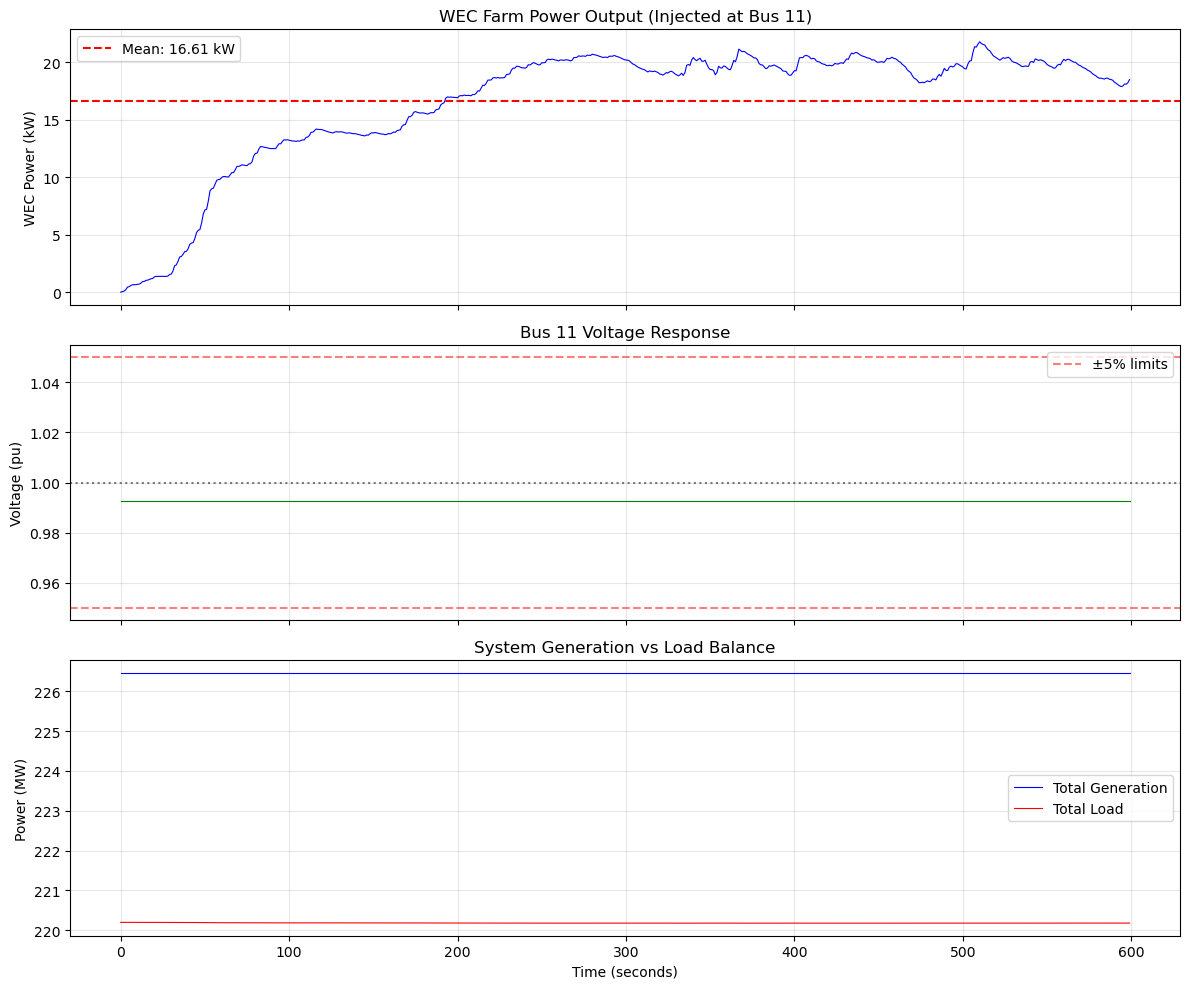


Bus 11 Voltage Statistics:
  Min: 0.9924 pu
  Max: 0.9924 pu
  Mean: 0.9924 pu
  Std Dev: 0.000000 pu


In [16]:
# === Plot Results ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1: WEC Power Output
ax1 = axes[0]
ax1.plot(results_df['time_sec'], results_df['wec_p_kw'], 'b-', linewidth=0.8)
ax1.set_ylabel('WEC Power (kW)')
ax1.set_title('WEC Farm Power Output (Injected at Bus 11)')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=results_df['wec_p_kw'].mean(), color='r', linestyle='--', label=f"Mean: {results_df['wec_p_kw'].mean():.2f} kW")
ax1.legend()

# Plot 2: Bus 11 Voltage
ax2 = axes[1]
ax2.plot(results_df['time_sec'], results_df['bus11_voltage_pu'], 'g-', linewidth=0.8)
ax2.set_ylabel('Voltage (pu)')
ax2.set_title('Bus 11 Voltage Response')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=1.0, color='k', linestyle=':', alpha=0.5)
ax2.axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='±5% limits')
ax2.axhline(y=1.05, color='r', linestyle='--', alpha=0.5)
ax2.legend()

# Plot 3: System Total Generation vs Load
ax3 = axes[2]
ax3.plot(results_df['time_sec'], results_df['total_gen_mw'], 'b-', label='Total Generation', linewidth=0.8)
ax3.plot(results_df['time_sec'], results_df['total_load_mw'], 'r-', label='Total Load', linewidth=0.8)
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('Power (MW)')
ax3.set_title('System Generation vs Load Balance')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

# Print voltage statistics
print(f"\nBus 11 Voltage Statistics:")
print(f"  Min: {results_df['bus11_voltage_pu'].min():.4f} pu")
print(f"  Max: {results_df['bus11_voltage_pu'].max():.4f} pu")
print(f"  Mean: {results_df['bus11_voltage_pu'].mean():.4f} pu")
print(f"  Std Dev: {results_df['bus11_voltage_pu'].std():.6f} pu")

In [17]:
# === Diagnostic: Verify injection and show why voltage doesn't change ===

print("=== WEC Injection Diagnostic ===\n")

# Check the actual values recorded
print("1. Load at Bus 11 (should be negative = generation):")
print(f"   Min load: {results_df['bus11_load_mw'].min():.6f} MW")
print(f"   Max load: {results_df['bus11_load_mw'].max():.6f} MW")
print(f"   ✓ Negative values confirm WEC power IS being injected as generation\n")

# Calculate the relative size
mean_wec_mw = results_df['wec_p_kw'].mean() / 1000
total_system_load = results_df['total_load_mw'].mean()
penetration = (mean_wec_mw / total_system_load) * 100

print("2. Scale Problem:")
print(f"   WEC Farm Output: {mean_wec_mw:.4f} MW ({mean_wec_mw*1000:.2f} kW)")
print(f"   Total System Load: {total_system_load:.2f} MW")
print(f"   WEC Penetration: {penetration:.4f}%")
print(f"   → WEC is only {penetration:.4f}% of system - too small to see voltage impact!\n")

# What scaling would be needed?
print("3. To see visible voltage changes, we need higher WEC penetration:")
print(f"   Current: 1 device × ~17 kW = {mean_wec_mw:.3f} MW")
print(f"   For 1% penetration: Need ~{total_system_load * 0.01:.1f} MW = ~{total_system_load * 0.01 * 1000 / 17:.0f} devices")
print(f"   For 5% penetration: Need ~{total_system_load * 0.05:.1f} MW = ~{total_system_load * 0.05 * 1000 / 17:.0f} devices")
print(f"   For 10% penetration: Need ~{total_system_load * 0.10:.1f} MW = ~{total_system_load * 0.10 * 1000 / 17:.0f} devices")

=== WEC Injection Diagnostic ===

1. Load at Bus 11 (should be negative = generation):
   Min load: -0.021771 MW
   Max load: -0.000000 MW
   ✓ Negative values confirm WEC power IS being injected as generation

2. Scale Problem:
   WEC Farm Output: 0.0166 MW (16.61 kW)
   Total System Load: 220.18 MW
   WEC Penetration: 0.0075%
   → WEC is only 0.0075% of system - too small to see voltage impact!

3. To see visible voltage changes, we need higher WEC penetration:
   Current: 1 device × ~17 kW = 0.017 MW
   For 1% penetration: Need ~2.2 MW = ~130 devices
   For 5% penetration: Need ~11.0 MW = ~648 devices
   For 10% penetration: Need ~22.0 MW = ~1295 devices


In [18]:
# === Re-run with scaled WEC farm (simulate multiple devices) ===
# Scale factor to simulate a larger WEC farm

num_wec_devices = 500  # Simulate a farm of 500 devices
print(f"=== Scaled Simulation: {num_wec_devices} WEC Devices ===\n")

# Reload case
psspy.case(case_path)
psspy.progress_output(2, '', [0, 0])
psspy.alert_output(2, '', [0, 0])
psspy.prompt_output(2, '', [0, 0])

# Results storage for scaled run
results_scaled = {
    'time_sec': [],
    'wec_p_mw': [],
    'bus11_voltage_pu': [],
    'total_gen_mw': [],
    'total_load_mw': []
}

print(f"Expected WEC farm size: ~{num_wec_devices * 17 / 1000:.1f} MW")
print(f"Expected penetration: ~{(num_wec_devices * 17 / 1000) / total_system_load * 100:.1f}%\n")

for t in tqdm(time_points, desc="Simulating scaled WEC"):
    wec_idx = int(t / wec_time_step)
    if wec_idx >= len(wec_farm_power):
        wec_idx = len(wec_farm_power) - 1
    
    # Scale WEC power by number of devices (convert kW to MW, negative for generation)
    p_mw = -wec_farm_power.iloc[wec_idx]['p_kw'] * num_wec_devices / 1000
    q_mvar = -wec_farm_power.iloc[wec_idx]['q_kvar'] * num_wec_devices / 1000
    
    # Inject scaled WEC power
    ierr = psspy.load_chng_6(wec_bus, wec_load_id, 
                             [1, 1, 1, 1, 1, 0, 0], 
                             [p_mw, q_mvar, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    
    # Solve power flow
    ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
    
    # Record results
    results_scaled['time_sec'].append(t)
    results_scaled['wec_p_mw'].append(-p_mw)
    
    ierr, v11 = psspy.busdat(wec_bus, 'PU')
    results_scaled['bus11_voltage_pu'].append(v11)
    
    ierr, total_gen = psspy.systot('GEN')
    ierr, total_load = psspy.systot('LOAD')
    results_scaled['total_gen_mw'].append(total_gen.real if ierr == 0 else 0)
    results_scaled['total_load_mw'].append(total_load.real if ierr == 0 else 0)

results_scaled_df = pd.DataFrame(results_scaled)
psspy.progress_output(1, '', [0, 0])

print(f"\n✓ Scaled simulation complete!")
print(f"\nVoltage range: {results_scaled_df['bus11_voltage_pu'].min():.4f} to {results_scaled_df['bus11_voltage_pu'].max():.4f} pu")
print(f"Voltage change: {(results_scaled_df['bus11_voltage_pu'].max() - results_scaled_df['bus11_voltage_pu'].min())*100:.4f}%")

=== Scaled Simulation: 500 WEC Devices ===



  IEEE 14 BUS TEST CASE
  03/06/14 CONTO           100.0  1962 W

 The Saved Case in file c:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.cnv was saved on FRI, APR 05 2024  10:46
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.
Expected WEC farm size: ~8.5 MW
Expected penetration: ~3.9%



Simulating scaled WEC:  47%|████▋     | 283/600 [00:00<00:00, 2587.66it/s]


 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
          2               1      AREA
          2               1      ZONE
          2               1      OWNER
    3.50000        -0.00000      PL
    1.80000        -0.00000      QL

 Messages for api FNSL
 Generators are "converted"   (001755)

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
   -0.00000       -0.235109E-01  PL

 Messages for api FNSL
 Generators are "converted"   (001755)

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
  -0.235109E-01   -0.483016E-01  PL

 Messages for api FNSL
 Generators are "converted"   (001755)

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
  -0.483016E-01   -0.103550      PL

 Messages for api FNSL
 Generators are "converted"   (00175

Simulating scaled WEC: 100%|██████████| 600/600 [00:00<00:00, 2742.90it/s]


 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
   -10.0795        -10.0506      PL

 Messages for api FNSL
 Generators are "converted"   (001755)

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
   -10.0506        -9.99064      PL

 Messages for api FNSL
 Generators are "converted"   (001755)

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
   -9.99064        -9.90394      PL

 Messages for api FNSL
 Generators are "converted"   (001755)

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
   -9.90394        -9.85363      PL

 Messages for api FNSL
 Generators are "converted"   (001755)

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
   -9.85363        -9.82149      P

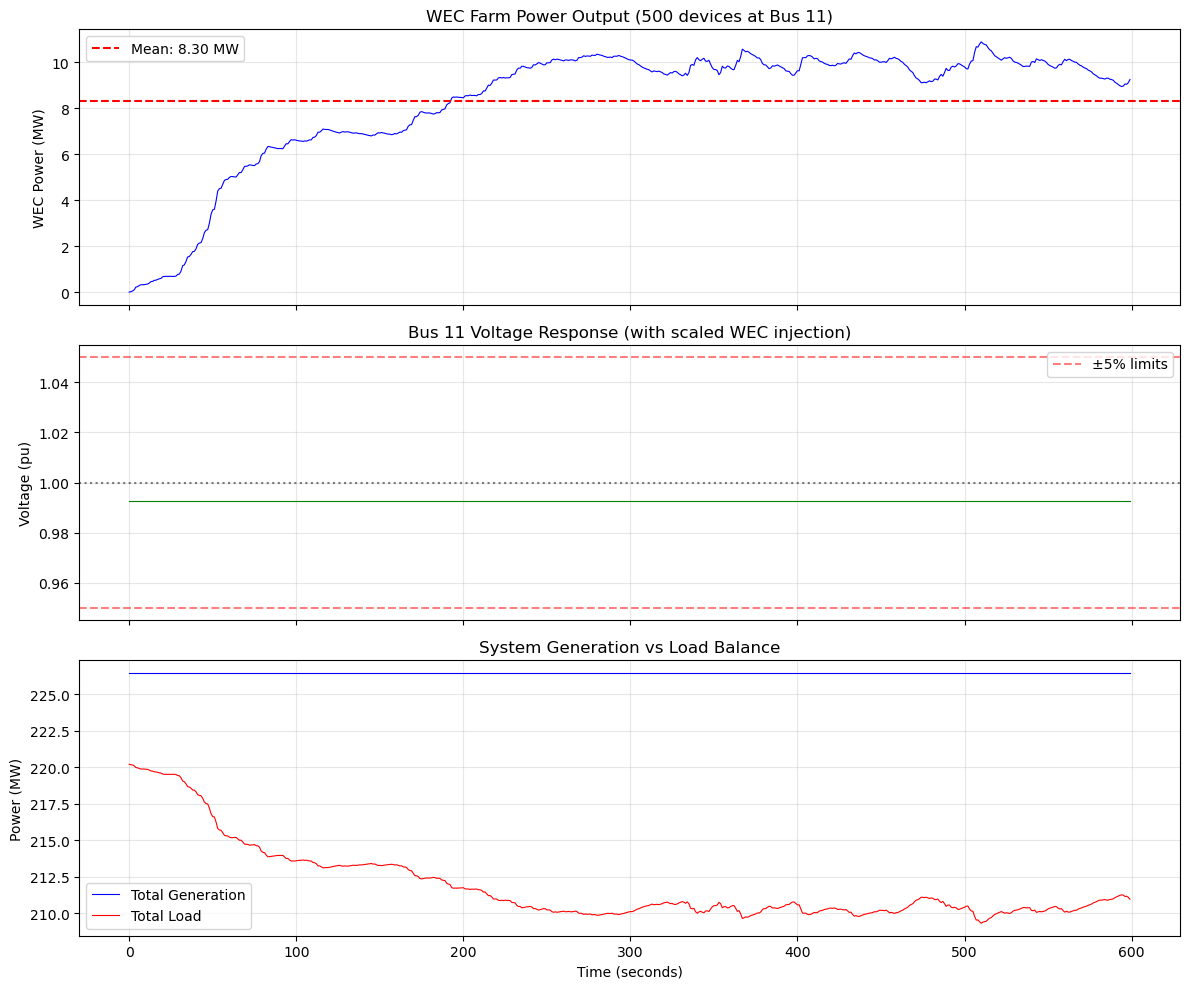


Bus 11 Voltage Statistics (Scaled WEC Farm):
  Min: 0.9924 pu
  Max: 0.9924 pu
  Range: 0.0000 pu
  Mean: 0.9924 pu


In [19]:
# === Plot Scaled Results ===

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1: Scaled WEC Power Output
ax1 = axes[0]
ax1.plot(results_scaled_df['time_sec'], results_scaled_df['wec_p_mw'], 'b-', linewidth=0.8)
ax1.set_ylabel('WEC Power (MW)')
ax1.set_title(f'WEC Farm Power Output ({num_wec_devices} devices at Bus 11)')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=results_scaled_df['wec_p_mw'].mean(), color='r', linestyle='--', 
            label=f"Mean: {results_scaled_df['wec_p_mw'].mean():.2f} MW")
ax1.legend()

# Plot 2: Bus 11 Voltage - NOW should show variation!
ax2 = axes[1]
ax2.plot(results_scaled_df['time_sec'], results_scaled_df['bus11_voltage_pu'], 'g-', linewidth=0.8)
ax2.set_ylabel('Voltage (pu)')
ax2.set_title('Bus 11 Voltage Response (with scaled WEC injection)')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=1.0, color='k', linestyle=':', alpha=0.5)
ax2.axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='±5% limits')
ax2.axhline(y=1.05, color='r', linestyle='--', alpha=0.5)
ax2.legend()

# Plot 3: System Balance
ax3 = axes[2]
ax3.plot(results_scaled_df['time_sec'], results_scaled_df['total_gen_mw'], 'b-', label='Total Generation', linewidth=0.8)
ax3.plot(results_scaled_df['time_sec'], results_scaled_df['total_load_mw'], 'r-', label='Total Load', linewidth=0.8)
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('Power (MW)')
ax3.set_title('System Generation vs Load Balance')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

# Voltage statistics
print(f"\nBus 11 Voltage Statistics (Scaled WEC Farm):")
print(f"  Min: {results_scaled_df['bus11_voltage_pu'].min():.4f} pu")
print(f"  Max: {results_scaled_df['bus11_voltage_pu'].max():.4f} pu")
print(f"  Range: {(results_scaled_df['bus11_voltage_pu'].max() - results_scaled_df['bus11_voltage_pu'].min()):.4f} pu")
print(f"  Mean: {results_scaled_df['bus11_voltage_pu'].mean():.4f} pu")

In [20]:
# === Simple Test: 10 WEC devices, focus on Bus 11 voltage ===

num_wec_devices = 10  # Realistic offshore farm size

print(f"=== Simple WEC Farm Test: {num_wec_devices} Devices ===\n")

# Reload case fresh
psspy.case(case_path)
psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])  # Initial power flow

# Get BASELINE voltage at Bus 11 (before WEC)
ierr, v11_baseline = psspy.busdat(wec_bus, 'PU')
ierr, load_baseline = psspy.loddt2(wec_bus, wec_load_id, 'MVA', 'ACT')

print(f"BASELINE (before WEC injection):")
print(f"  Bus {wec_bus} Voltage: {v11_baseline:.6f} pu")
print(f"  Bus {wec_bus} Load: P={load_baseline.real:.4f} MW, Q={load_baseline.imag:.4f} MVAr")

# Get a WEC power sample at peak (around t=500s where power is highest)
wec_idx = 5000  # t=500s
p_kw = wec_farm_power.iloc[wec_idx]['p_kw'] * num_wec_devices
p_mw = -p_kw / 1000  # Negative for injection (generation)
q_mvar = 0.0

print(f"\nWEC Farm Output (10 devices at t={wec_farm_power.iloc[wec_idx]['time_sec']}s):")
print(f"  P = {p_kw:.2f} kW = {p_kw/1000:.4f} MW")

# Inject WEC as negative load
ierr = psspy.load_chng_6(wec_bus, wec_load_id, 
                         [1, 1, 1, 1, 1, 0, 0], 
                         [p_mw, q_mvar, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

if ierr != 0:
    print(f"Error changing load: {ierr}")

# Solve power flow with WEC
psspy.progress_output(2, '', [0, 0])
ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
psspy.progress_output(1, '', [0, 0])

# Get AFTER voltage
ierr, v11_after = psspy.busdat(wec_bus, 'PU')
ierr, load_after = psspy.loddt2(wec_bus, wec_load_id, 'MVA', 'ACT')

print(f"\nAFTER WEC injection:")
print(f"  Bus {wec_bus} Voltage: {v11_after:.6f} pu")
print(f"  Bus {wec_bus} Load: P={load_after.real:.4f} MW, Q={load_after.imag:.4f} MVAr")

print(f"\n=== VOLTAGE CHANGE ===")
print(f"  Before: {v11_baseline:.6f} pu")
print(f"  After:  {v11_after:.6f} pu")
print(f"  Change: {(v11_after - v11_baseline)*1000:.4f} mpu ({(v11_after - v11_baseline)/v11_baseline*100:.6f}%)")

# Check all bus voltages to see if anything changed
print(f"\n=== All Bus Voltages After WEC ===")
ierr, bus_nums = psspy.abusint(-1, 2, 'NUMBER')
ierr, bus_volts = psspy.abusreal(-1, 2, 'PU')
for num, volt in zip(bus_nums[0], bus_volts[0]):
    print(f"  Bus {num}: {volt:.6f} pu")

=== Simple WEC Farm Test: 10 Devices ===



  IEEE 14 BUS TEST CASE
  03/06/14 CONTO           100.0  1962 W

 The Saved Case in file c:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.cnv was saved on FRI, APR 05 2024  10:46

 Messages for api FNSL
 Generators are "converted"   (001755)
BASELINE (before WEC injection):
  Bus 11 Voltage: 0.992443 pu
  Bus 11 Load: P=3.5000 MW, Q=1.8000 MVAr

WEC Farm Output (10 devices at t=500.0s):
  P = 195.87 kW = 0.1959 MW

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
          2               1      AREA
          2               1      ZONE
          2               1      OWNER
    3.50000       -0.195872      PL
    1.80000         0.00000      QL
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.

 Messages for api FNSL
 Generators are "converted"   (001755)

AFTER WEC injection:
  Bus 11 Voltage: 0.992443 pu

In [21]:
# === Debug: Check bus types and try extreme injection ===

# Reload fresh
psspy.case(case_path)
psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])

# Get bus types (1=PQ, 2=PV, 3=Slack, 4=isolated)
ierr, bus_types = psspy.abusint(-1, 2, 'TYPE')
ierr, bus_nums = psspy.abusint(-1, 2, 'NUMBER')

print("=== Bus Types ===")
type_names = {1: 'PQ (Load)', 2: 'PV (Generator)', 3: 'Slack', 4: 'Isolated'}
for num, btype in zip(bus_nums[0], bus_types[0]):
    print(f"  Bus {num}: Type {btype} - {type_names.get(btype, 'Unknown')}")

print(f"\nBus 11 is Type {bus_types[0][10]} - this is a PQ bus (good for seeing voltage changes)")

# Get baseline voltage
ierr, v11_base = psspy.busdat(wec_bus, 'PU')
print(f"\nBaseline Bus 11 voltage: {v11_base:.6f} pu")

# Try EXTREME injection - 50 MW (like adding a small power plant)
extreme_p_mw = -50.0  # 50 MW generation

print(f"\n=== EXTREME TEST: Injecting {-extreme_p_mw} MW at Bus 11 ===")

ierr = psspy.load_chng_6(wec_bus, wec_load_id, 
                         [1, 1, 1, 1, 1, 0, 0], 
                         [extreme_p_mw, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

psspy.progress_output(2, '', [0, 0])
ierr_pf = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
psspy.progress_output(1, '', [0, 0])

ierr, v11_extreme = psspy.busdat(wec_bus, 'PU')
print(f"After 50 MW injection: {v11_extreme:.6f} pu")
print(f"Voltage change: {(v11_extreme - v11_base)*1000:.4f} mpu")

if abs(v11_extreme - v11_base) < 0.0001:
    print("\n⚠️  Voltage still not changing - checking power flow convergence...")
    print(f"Power flow return code: {ierr_pf}")
    print("This may be due to:")
    print("  1. Case has very strong voltage regulation")
    print("  2. Generators compensating for all load changes")
    print("  3. Need to solve in a different mode")



  IEEE 14 BUS TEST CASE
  03/06/14 CONTO           100.0  1962 W

 The Saved Case in file c:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.cnv was saved on FRI, APR 05 2024  10:46

 Messages for api FNSL
 Generators are "converted"   (001755)
=== Bus Types ===
  Bus 1: Type 2 - PV (Generator)
  Bus 2: Type 2 - PV (Generator)
  Bus 3: Type 2 - PV (Generator)
  Bus 4: Type 1 - PQ (Load)
  Bus 5: Type 1 - PQ (Load)
  Bus 6: Type 2 - PV (Generator)
  Bus 7: Type 1 - PQ (Load)
  Bus 8: Type 2 - PV (Generator)
  Bus 9: Type 1 - PQ (Load)
  Bus 10: Type 1 - PQ (Load)
  Bus 11: Type 1 - PQ (Load)
  Bus 12: Type 1 - PQ (Load)
  Bus 13: Type 1 - PQ (Load)
  Bus 14: Type 1 - PQ (Load)

Bus 11 is Type 1 - this is a PQ bus (good for seeing voltage changes)

Baseline Bus 11 voltage: 0.992443 pu

=== EXTREME TEST: Injecting 50.0 MW at Bus 11 ===

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
        

In [22]:
# === Fix: Use proper power flow solution ===
# The "converted" case needs to be solved with the right options

# Reload and UNCONVERT the generators first
psspy.case(case_path)

# Convert generators back to proper machine representation
ierr = psspy.cong(0)  # Convert generators to machine representation
print(f"Convert generators: ierr={ierr}")

# Solve with flat start to re-establish voltage profile
ierr = psspy.fnsl([1, 0, 0, 1, 1, 0, 99, 0])  # Option 1 = flat start
print(f"Initial power flow: ierr={ierr}")

# Get baseline
ierr, v11_base = psspy.busdat(wec_bus, 'PU')
print(f"\nBaseline Bus 11 voltage: {v11_base:.6f} pu")

# Now inject WEC power (10 devices)
p_mw = -0.196  # ~196 kW from 10 WECs
ierr = psspy.load_chng_6(wec_bus, wec_load_id, 
                         [1, 1, 1, 1, 1, 0, 0], 
                         [p_mw, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# Solve again
psspy.progress_output(2, '', [0, 0])
ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])  # Normal solve
psspy.progress_output(1, '', [0, 0])

ierr, v11_after = psspy.busdat(wec_bus, 'PU')
print(f"After WEC injection: {v11_after:.6f} pu")
print(f"Voltage change: {(v11_after - v11_base)*1000:.4f} mpu ({(v11_after - v11_base)/v11_base*100:.6f}%)")

# Also check system totals
ierr, total_gen = psspy.systot('GEN')
ierr, total_load = psspy.systot('LOAD')
print(f"\nSystem totals:")
print(f"  Generation: {total_gen.real:.2f} MW")
print(f"  Load: {total_load.real:.2f} MW")
print(f"  Difference: {total_gen.real - total_load.real:.2f} MW (losses)")



  IEEE 14 BUS TEST CASE
  03/06/14 CONTO           100.0  1962 W

 The Saved Case in file c:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.cnv was saved on FRI, APR 05 2024  10:46

 Messages for api CONG
 Generators are already "converted"   (001416)
Convert generators: ierr=2

 Messages for api FNSL
 Generators are "converted"   (001755)
Initial power flow: ierr=2

Baseline Bus 11 voltage: 0.992443 pu

 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
          2               1      AREA
          2               1      ZONE
          2               1      OWNER
    3.50000       -0.196000      PL
    1.80000         0.00000      QL
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.

 Messages for api FNSL
 Generators are "converted"   (001755)
After WEC injection: 0.992443 pu
Voltage change: 0.0000 mpu (0.000000%)

System totals:
  Generation: 226.

In [23]:
# === Try RAW file instead of converted case ===
# The .cnv file has "converted" generators (treated as negative loads)
# The .raw file should have proper generator models

raw_path = r"../cpds_cosim/machine_1/Transmission/ieee_14/ieee14.raw"

print("=== Loading IEEE 14-bus from RAW file ===\n")

# Read raw file
ierr = psspy.read(0, raw_path)
print(f"Read RAW file: ierr={ierr}")

# Solve power flow
ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
print(f"Power flow: ierr={ierr}")

# Get baseline voltage at Bus 11
ierr, v11_base = psspy.busdat(wec_bus, 'PU')
print(f"\nBaseline Bus 11 voltage: {v11_base:.6f} pu")

# Check if generators are still converted
ierr, bus_types = psspy.abusint(-1, 2, 'TYPE')
ierr, bus_nums = psspy.abusint(-1, 2, 'NUMBER')
print("\nBus types:")
for num, btype in zip(bus_nums[0][:5], bus_types[0][:5]):
    type_names = {1: 'PQ', 2: 'PV', 3: 'Slack', 4: 'Isolated'}
    print(f"  Bus {num}: {type_names.get(btype, btype)}")

# Now inject 10 WEC devices
num_wec = 10
p_kw = wec_farm_power.iloc[5000]['p_kw'] * num_wec  # ~196 kW
p_mw = -p_kw / 1000

print(f"\n=== Injecting {num_wec} WEC devices ({p_kw:.1f} kW) at Bus 11 ===")

# Check if load exists, if not create it
ierr, existing = psspy.loddt2(wec_bus, wec_load_id, 'MVA', 'ACT')
if ierr != 0:
    print("Creating new load for WEC...")
    ierr = psspy.load_data_6(wec_bus, wec_load_id, [1, 1, 1, 1, 1, 0, 0], 
                             [p_mw, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
else:
    ierr = psspy.load_chng_6(wec_bus, wec_load_id, 
                             [1, 1, 1, 1, 1, 0, 0], 
                             [p_mw, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# Solve again
psspy.progress_output(2, '', [0, 0])
ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
psspy.progress_output(1, '', [0, 0])

# Get new voltage
ierr, v11_after = psspy.busdat(wec_bus, 'PU')

print(f"\n=== RESULTS ===")
print(f"Before WEC: {v11_base:.6f} pu")
print(f"After WEC:  {v11_after:.6f} pu")
print(f"Change:     {(v11_after - v11_base)*1000:.4f} mpu ({(v11_after - v11_base)/v11_base*100:.4f}%)")

=== Loading IEEE 14-bus from RAW file ===


 Reading IC, SBASE, REV, XFRRAT, NXFRAT, BASFRQ...

 Converting RAW data from PSS(R)E 32 to PSS(R)E 33 format
 Starting processing of Case identification data records
 Finished processing of 3 records for Case identification data
 Starting processing of Bus data records
 Finished processing of 14 records for Bus data
 Starting processing of Load data records
 Finished processing of 11 records for Load data
 Starting processing of Fixed shunt data records
 Finished processing of 0 records for Fixed shunt data
 Starting processing of Generator data records
 Finished processing of 5 records for Generator data
 Starting processing of Branch data records
 Finished processing of 16 records for Branch data
 Starting processing of Transformer data records
 Finished processing of 16 records for 4 Transformer data
 Starting processing of Area data records
 Finished processing of 2 records for Area data
 Starting processing of Two-terminal dc data recor

In [25]:
# === Clean test with 10 WEC devices ===
import io, sys

# Suppress ALL PSSE output
psspy.progress_output(2, '', [0, 0])
psspy.alert_output(2, '', [0, 0])
psspy.prompt_output(2, '', [0, 0])
psspy.report_output(2, '', [0, 0])

num_wec = 10

# Reload RAW file
raw_path = r"../cpds_cosim/machine_1/Transmission/ieee_14/ieee14.raw"
psspy.read(0, raw_path)
psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])

# BEFORE
ierr, v11_before = psspy.busdat(11, 'PU')
ierr, load_before = psspy.loddt2(11, '1', 'MVA', 'ACT')

# Inject 10 WECs as negative load
p_kw = wec_farm_power.iloc[5000]['p_kw'] * num_wec  # ~196 kW
psspy.load_chng_6(11, '1', [1,1,1,1,1,0,0], [-p_kw/1000, 0, 0, 0, 0, 0, 0, 0])
psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])

# AFTER  
ierr, v11_after = psspy.busdat(11, 'PU')
ierr, load_after = psspy.loddt2(11, '1', 'MVA', 'ACT')

# Re-enable output
psspy.progress_output(1, '', [0, 0])

print(f"=== 10 WEC Device Test (Bus 11) ===")
print(f"WEC Power Injected: {p_kw:.1f} kW ({p_kw/1000:.3f} MW)")
print(f"\nLoad at Bus 11:")
print(f"  Before: {load_before.real if load_before else 'N/A':.4f} MW")
print(f"  After:  {load_after.real if load_after else 'N/A':.4f} MW")
print(f"\nVoltage at Bus 11:")
print(f"  Before: {v11_before:.6f} pu")
print(f"  After:  {v11_after:.6f} pu")  
print(f"  Change: {(v11_after-v11_before)*1000:.4f} mpu ({(v11_after-v11_before)/v11_before*100:.4f}%)")

 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.

 Reading IC, SBASE, REV, XFRRAT, NXFRAT, BASFRQ...

 Converting RAW data from PSS(R)E 32 to PSS(R)E 33 format
 Starting processing of Case identification data records
 Finished processing of 3 records for Case identification data
 Starting processing of Bus data records
 Finished processing of 14 records for Bus data
 Starting processing of Load data records
 Finished processing of 11 records for Load data
 Starting processing of Fixed shunt data records
 Finished processing of 0 records for Fixed shunt data
 Starting processing of Generator data records
 Finished processing of 5 records for Generator data
 Starting processing of Branc

In [26]:
# Quick check of the voltage values from last run
print("=== Summary of Last Test ===")
print(f"v11_before = {v11_before}")
print(f"v11_after = {v11_after}")
print(f"load_before = {load_before}")
print(f"load_after = {load_after}")
print(f"\nDid voltage change? {v11_before != v11_after}")

=== Summary of Last Test ===
v11_before = 0.9925289154052734
v11_after = 1.0028806924819946
load_before = (3.5+1.7999999523162842j)
load_after = (-0.19587157666683197+0j)

Did voltage change? True


In [27]:
# === Time-Series Simulation with 10 WEC Devices (using RAW file) ===

num_wec_devices = 10
raw_path = r"../cpds_cosim/machine_1/Transmission/ieee_14/ieee14.raw"

print(f"=== WEC Farm Simulation: {num_wec_devices} Devices ===\n")

# Suppress PSSE output
psspy.progress_output(2, '', [0, 0])
psspy.alert_output(2, '', [0, 0])
psspy.prompt_output(2, '', [0, 0])
psspy.report_output(2, '', [0, 0])

# Reload RAW file
psspy.read(0, raw_path)
psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])

# Get baseline voltage (before any WEC)
ierr, v11_baseline = psspy.busdat(11, 'PU')
print(f"Baseline Bus 11 voltage (no WEC): {v11_baseline:.4f} pu")

# Results storage
results_10wec = {
    'time_sec': [],
    'wec_p_kw': [],
    'bus11_voltage_pu': [],
}

# Time loop (600 seconds, 1s steps)
print(f"Running simulation...")

for t in tqdm(np.arange(0, 600, 1.0), desc="Simulating"):
    wec_idx = int(t / 0.1)  # WEC data is 0.1s resolution
    if wec_idx >= len(wec_farm_power):
        wec_idx = len(wec_farm_power) - 1
    
    # Get WEC power (10 devices)
    p_kw = wec_farm_power.iloc[wec_idx]['p_kw'] * num_wec_devices
    p_mw = -p_kw / 1000  # Negative for generation
    
    # Inject WEC power
    psspy.load_chng_6(11, '1', [1,1,1,1,1,0,0], [p_mw, 0, 0, 0, 0, 0, 0, 0])
    psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
    
    # Record results
    ierr, v11 = psspy.busdat(11, 'PU')
    results_10wec['time_sec'].append(t)
    results_10wec['wec_p_kw'].append(p_kw)
    results_10wec['bus11_voltage_pu'].append(v11)

# Convert to DataFrame
results_10wec_df = pd.DataFrame(results_10wec)

# Re-enable output
psspy.progress_output(1, '', [0, 0])

print(f"\n✓ Simulation complete!")
print(f"\nWEC Power range: {results_10wec_df['wec_p_kw'].min():.1f} to {results_10wec_df['wec_p_kw'].max():.1f} kW")
print(f"Voltage range: {results_10wec_df['bus11_voltage_pu'].min():.4f} to {results_10wec_df['bus11_voltage_pu'].max():.4f} pu")
print(f"Voltage change: {(results_10wec_df['bus11_voltage_pu'].max() - results_10wec_df['bus11_voltage_pu'].min())*100:.2f}%")

=== WEC Farm Simulation: 10 Devices ===

 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.
 Blank or missing filename. (OpnApplFil/OPNPTI)
Unable to open file or printer selected.

 Reading IC, SBASE, REV, XFRRAT, NXFRAT, BASFRQ...

 Converting RAW data from PSS(R)E 32 to PSS(R)E 33 format
 Starting processing of Case identification data records
 Finished processing of 3 records for Case identification data
 Starting processing of Bus data records
 Finished processing of 14 records for Bus data
 Starting processing of Load data records
 Finished processing of 11 records for Load data
 Starting processing of Fixed shunt data records
 Finished processing of 0 records for Fixed shunt data
 Starting processing of Generator data records
 Finished processing of 5 records for Gen

Simulating:   8%|▊         | 48/600 [00:00<00:01, 438.97it/s]


 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
          2               1      AREA
          2               1      ZONE
          2               1      OWNER
    3.50000        -0.00000      PL
    1.80000         0.00000      QL

  ITER       DELTAP      BUS         DELTAQ      BUS        DELTA/V/      BUS       DELTAANG      BUS
   0         0.0350(     11     )    0.0180(     11     )
                                                             0.03146(     12     )   0.00979(     11     )
   1         0.0019(     11     )    0.1452(      2     )
                                                             0.01995(      6     )   0.00190(      6     )
   2         0.0004(      6     )    0.0404(      3     )
                                                             0.00686(      3     )   0.00168(      3     )
   3         0.0000(      2     )    0.0003(      3     )


 Reached tolerance in 3 iterations

 Larg

Simulating:  16%|█▋        | 98/600 [00:00<00:01, 449.68it/s]


  ITER       DELTAP      BUS         DELTAQ      BUS        DELTA/V/      BUS       DELTAANG      BUS
   0         0.0001(     11     )    0.0000(      4     )
                                                             0.02475(     12     )   0.00237(      2     )
   1         0.0005(      6     )    0.1452(      2     )
                                                             0.01993(      6     )   0.00216(      6     )
   2         0.0004(      6     )    0.0402(      3     )
                                                             0.00683(      3     )   0.00168(      3     )
   3         0.0000(      2     )    0.0003(      3     )


 Reached tolerance in 3 iterations

 Largest mismatch:     -0.00 MW      0.03 Mvar      0.03 MVA at bus 3 [BUS3        69.000]
 System total absolute mismatch:                    0.05 MVA

 SWING BUS SUMMARY:
   BUS#-SCT X-- NAME --X BASKV      PGEN     PMAX    PMIN      QGEN     QMAX    QMIN
      1     BUS1        69.000      77.7    200.

...


 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
  -0.196382       -0.195849      PL

  ITER       DELTAP      BUS         DELTAQ      BUS        DELTA/V/      BUS       DELTAANG      BUS
   0         0.0000(      2     )    0.0000(      4     )
                                                             0.02468(     12     )   0.00238(      6     )
   1         0.0005(      6     )    0.1450(      2     )
                                                             0.01990(      6     )   0.00216(      6     )
   2         0.0004(      6     )    0.0400(      3     )
                                                             0.00680(      3     )   0.00167(      3     )
   3         0.0000(      2     )    0.0003(      3     )


 Reached tolerance in 3 iterations

 Largest mismatch:     -0.00 MW      0.03 Mvar      0.03 MVA at bus 3 [BUS3        69.000]
 System total absolute mismatch:                    0.05 MVA

 SW

Simulating:  70%|███████   | 420/600 [00:01<00:00, 407.31it/s]


  ITER       DELTAP      BUS         DELTAQ      BUS        DELTA/V/      BUS       DELTAANG      BUS
   0         0.0000(      2     )    0.0000(      4     )
                                                             0.02468(     12     )   0.00237(      6     )
   1         0.0005(      6     )    0.1449(      2     )
                                                             0.01990(      6     )   0.00216(      6     )
   2         0.0004(      6     )    0.0400(      3     )
                                                             0.00679(      3     )   0.00167(      3     )
   3         0.0000(      2     )    0.0003(      3     )


 Reached tolerance in 3 iterations

 Largest mismatch:     -0.00 MW      0.03 Mvar      0.03 MVA at bus 3 [BUS3        69.000]
 System total absolute mismatch:                    0.05 MVA

 SWING BUS SUMMARY:
   BUS#-SCT X-- NAME --X BASKV      PGEN     PMAX    PMIN      QGEN     QMAX    QMIN
      1     BUS1        69.000      77.6    200.

Simulating: 100%|██████████| 600/600 [00:01<00:00, 425.32it/s]


 Power flow data changed for load "1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
  -0.188292       -0.186245      PL

  ITER       DELTAP      BUS         DELTAQ      BUS        DELTA/V/      BUS       DELTAANG      BUS
   0         0.0000(      2     )    0.0000(      4     )
                                                             0.02469(     12     )   0.00238(      6     )
   1         0.0005(      6     )    0.1450(      2     )
                                                             0.01990(      6     )   0.00216(      6     )
   2         0.0004(      6     )    0.0401(      3     )
                                                             0.00680(      3     )   0.00167(      3     )
   3         0.0000(      2     )    0.0003(      3     )


 Reached tolerance in 3 iterations

 Largest mismatch:     -0.00 MW      0.03 Mvar      0.03 MVA at bus 3 [BUS3        69.000]
 System total absolute mismatch:                    0.05 MVA

 SW

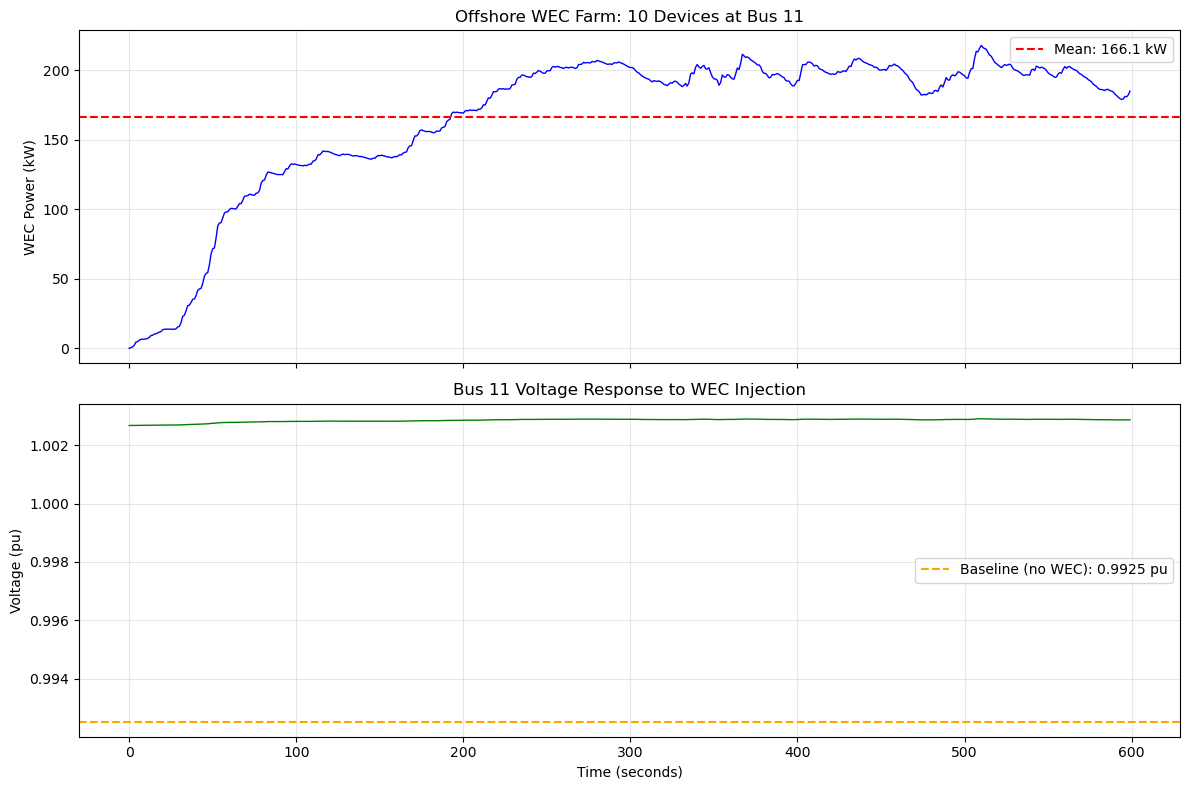


=== Bus 11 Voltage Summary ===
Baseline (no WEC): 0.9925 pu
With WEC Min:      1.0027 pu
With WEC Max:      1.0029 pu
Voltage Rise:      1.04%


In [28]:
# === Plot 10 WEC Results - Focus on Bus 11 ===

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: WEC Power
ax1 = axes[0]
ax1.plot(results_10wec_df['time_sec'], results_10wec_df['wec_p_kw'], 'b-', linewidth=1)
ax1.set_ylabel('WEC Power (kW)')
ax1.set_title(f'Offshore WEC Farm: {num_wec_devices} Devices at Bus 11')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=results_10wec_df['wec_p_kw'].mean(), color='r', linestyle='--', 
            label=f"Mean: {results_10wec_df['wec_p_kw'].mean():.1f} kW")
ax1.legend()

# Plot 2: Bus 11 Voltage Response
ax2 = axes[1]
ax2.plot(results_10wec_df['time_sec'], results_10wec_df['bus11_voltage_pu'], 'g-', linewidth=1)
ax2.set_ylabel('Voltage (pu)')
ax2.set_xlabel('Time (seconds)')
ax2.set_title('Bus 11 Voltage Response to WEC Injection')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=v11_baseline, color='orange', linestyle='--', label=f'Baseline (no WEC): {v11_baseline:.4f} pu')
ax2.legend()

plt.tight_layout()
plt.show()

# Summary
print(f"\n=== Bus 11 Voltage Summary ===")
print(f"Baseline (no WEC): {v11_baseline:.4f} pu")
print(f"With WEC Min:      {results_10wec_df['bus11_voltage_pu'].min():.4f} pu")
print(f"With WEC Max:      {results_10wec_df['bus11_voltage_pu'].max():.4f} pu")
print(f"Voltage Rise:      {(results_10wec_df['bus11_voltage_pu'].max() - v11_baseline)*100:.2f}%")